In [1]:
# This code works in Python 3.10.6
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx
import dgl
from torch_geometric.datasets.dblp import DBLP
from sklearn.mixture import GaussianMixture
import random
import torch
from torch import optim
import torch_geometric.utils.convert
from torch_geometric.data import HeteroData
import torch_geometric.transforms as T
import torch.nn.functional as F
from torch_geometric.nn import HeteroConv, Linear, SAGEConv
import seaborn as sns
from collections import Counter
import itertools
import community as community_louvain
import matplotlib.cm as cm
import os
import glob
import warnings
warnings.filterwarnings('ignore')

Create Metagraph

In [2]:
dataset = DBLP(root='./dblp_data', transform=T.Constant(node_types='conference'))
data = dataset[0]
data['conference'].pop('num_nodes')
#Create metagraph
g = torch_geometric.utils.convert.to_dgl(data)
meta_g= g.metagraph()

Original DBLP dataset with all node features

In [3]:
dataset = DBLP(root='./dblp_data', transform=T.Constant(node_types='conference'))
data = dataset[0]
print(data)

HeteroData(
  author={
    x=[4057, 334],
    y=[4057],
    train_mask=[4057],
    val_mask=[4057],
    test_mask=[4057],
  },
  paper={ x=[14328, 4231] },
  term={ x=[7723, 50] },
  conference={
    num_nodes=20,
    x=[20, 1],
  },
  (author, to, paper)={ edge_index=[2, 19645] },
  (paper, to, author)={ edge_index=[2, 19645] },
  (paper, to, term)={ edge_index=[2, 85810] },
  (paper, to, conference)={ edge_index=[2, 14328] },
  (term, to, paper)={ edge_index=[2, 85810] },
  (conference, to, paper)={ edge_index=[2, 14328] }
)


In [4]:
author = data['author'].x.tolist()
df = pd.DataFrame(data['author'].x)
df['class'] = data['author'].y.tolist()

In [5]:
def get_selected_features(X):

    col_sum = X.sum(axis=0)
    sorted_colsum = sorted(col_sum, reverse=True)
    colsum_df = pd.DataFrame(col_sum)
    
    sorted_colsum = sorted(col_sum, reverse=True)[:2]
    index_list = list(np.ravel(colsum_df[colsum_df[0].isin(sorted_colsum)].index))
    
    imp_feat = X[index_list]
    #imp_feat = imp_feat.drop(imp_feat[imp_feat.sum(axis=1) == 0.0].index)


    return imp_feat

In [6]:
author_class0 = df[df['class'] == 0].drop(['class'], axis = 1)
class0 = get_selected_features(author_class0)
cols = [i for i in range(0,len(class0.columns))]
class0.columns = cols
class0

,0,1
15,0.0,0.0
17,1.0,0.0
30,1.0,0.0
33,1.0,0.0
34,1.0,0.0
...,...,...
4052,1.0,0.0
4053,0.0,0.0
4054,0.0,0.0
4055,0.0,0.0


In [7]:
author_class1 = df[df['class'] == 1].drop(['class'], axis = 1)
class1 = get_selected_features(author_class1)
cols = [i for i in range(0,len(class1.columns))]
class1.columns = cols
class1

,0,1
4,0.0,0.0
9,0.0,0.0
13,1.0,1.0
23,1.0,0.0
24,0.0,0.0
...,...,...
3667,0.0,0.0
3686,0.0,0.0
3821,1.0,0.0
3956,1.0,0.0


In [8]:
author_class2 = df[df['class'] == 2].drop(['class'], axis = 1)
class2 = get_selected_features(author_class2)
cols = [i for i in range(0,len(class2.columns))]
class2.columns = cols
class2

,0,1
0,0.0,0.0
1,0.0,0.0
3,1.0,1.0
5,1.0,0.0
6,0.0,0.0
...,...,...
3459,1.0,0.0
3499,0.0,1.0
3515,0.0,1.0
3594,1.0,0.0


In [9]:
author_class3 = df[df['class'] == 3].drop(['class'], axis = 1)
class3 = get_selected_features(author_class3)
cols = [i for i in range(0,len(class3.columns))]
class3.columns = cols
class3

,0,1
2,1.0,0.0
12,0.0,0.0
20,0.0,1.0
21,1.0,1.0
35,0.0,1.0
...,...,...
3886,0.0,0.0
3887,0.0,0.0
3888,0.0,0.0
3889,0.0,0.0


In [10]:
paper = data['paper'].x.tolist()

df_paper = get_selected_features(pd.DataFrame(paper))   
df_paper

,11,31
0,1.0,0.0
1,1.0,0.0
2,1.0,1.0
3,1.0,0.0
4,1.0,0.0
...,...,...
14323,0.0,1.0
14324,1.0,0.0
14325,1.0,1.0
14326,1.0,1.0


In [11]:
term = pd.DataFrame(data['term'].x.numpy())
corr = term.corr()
m = ~(corr.mask(np.eye(len(corr), dtype=bool)).abs() > 0.9).any()
real = corr.loc[m]
list_index = np.ravel(real.index).tolist()
df_term = term[list_index]
df_term

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,-0.69241,-0.465920,1.154000,0.066483,-0.676250,0.693760,0.53680,0.206780,0.12607,-0.36763,...,1.32870,0.074684,-0.34136,0.873600,-0.065725,-0.780720,0.902000,0.917840,0.19945,-0.63601
1,1.20310,-0.400280,0.073991,1.041500,0.051753,0.411660,-0.98656,-0.794660,0.36033,0.54428,...,0.38339,-0.572190,-0.16915,0.139840,-0.774300,-0.061819,0.218870,1.326200,-0.33245,0.81980
2,0.37481,0.573140,0.480170,-0.056679,0.704740,0.715910,0.32591,-0.099446,0.51029,0.64193,...,0.74200,-0.163610,0.44295,0.400600,-0.235400,-0.276530,-0.203020,1.152200,0.60099,-0.43094
3,0.54148,-0.419840,-0.334260,-0.412010,0.112200,1.047600,0.47449,-0.751110,0.40817,0.74477,...,0.45971,-0.064420,-0.27582,1.021800,-0.037676,-0.405910,1.231400,0.472220,0.69127,0.37195
4,0.16408,0.927990,-1.573400,-0.859870,0.369720,0.852800,0.20269,-0.620400,-1.00010,0.29585,...,0.66077,-0.952820,-0.36583,1.758900,-0.497820,0.599950,0.756170,1.384800,-0.11633,-0.62254
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7718,0.41800,0.249680,-0.412420,0.121700,0.345270,-0.044457,-0.49688,-0.178620,-0.00066,-0.65660,...,-0.29871,-0.157490,-0.34758,-0.045637,-0.442510,0.187850,0.002785,-0.184110,-0.11514,-0.78581
7719,-1.01450,1.239400,-1.618500,-1.033600,-0.056811,0.270890,-0.38817,-0.353350,-0.51784,1.10460,...,0.97806,0.158320,-0.54189,-0.186700,-0.334690,0.391300,0.524110,-0.059546,-0.78882,-0.71343
7720,0.41800,0.249680,-0.412420,0.121700,0.345270,-0.044457,-0.49688,-0.178620,-0.00066,-0.65660,...,-0.29871,-0.157490,-0.34758,-0.045637,-0.442510,0.187850,0.002785,-0.184110,-0.11514,-0.78581
7721,0.17239,-0.272270,-1.336800,1.170600,-0.621270,-0.528470,1.32210,0.145990,-0.15398,-1.24660,...,-0.76113,-0.583970,-0.13828,0.907620,-0.114690,-0.746190,0.723290,-0.088101,0.02252,0.11660


In [12]:
author_node_features = get_selected_features(pd.DataFrame(author))   
author_node_features

,23,63
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,1.0,0.0
4,0.0,0.0
...,...,...
4052,0.0,1.0
4053,0.0,0.0
4054,0.0,0.0
4055,0.0,0.0


In [13]:
data['author'].x = torch.tensor(author_node_features.values).to(dtype=torch.float32)
data['paper'].x = torch.tensor(df_paper.values).to(dtype=torch.float32)
data['term'].x = torch.tensor(df_term.values).to(dtype=torch.float32)

In [14]:
data

HeteroData(
  author={
    x=[4057, 2],
    y=[4057],
    train_mask=[4057],
    val_mask=[4057],
    test_mask=[4057],
  },
  paper={ x=[14328, 2] },
  term={ x=[7723, 50] },
  conference={
    num_nodes=20,
    x=[20, 1],
  },
  (author, to, paper)={ edge_index=[2, 19645] },
  (paper, to, author)={ edge_index=[2, 19645] },
  (paper, to, term)={ edge_index=[2, 85810] },
  (paper, to, conference)={ edge_index=[2, 14328] },
  (term, to, paper)={ edge_index=[2, 85810] },
  (conference, to, paper)={ edge_index=[2, 14328] }
)

In [15]:
class HeteroGNN(torch.nn.Module):
    def __init__(self, metadata, hidden_channels, out_channels, num_layers):
        super().__init__()

        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            conv = HeteroConv({
                edge_type: SAGEConv((-1, -1), hidden_channels)
                for edge_type in metadata[1]
            })
            self.convs.append(conv)

        self.lin = Linear(hidden_channels, out_channels)

    def forward(self, x_dict, edge_index_dict):
        for conv in self.convs:
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {key: F.leaky_relu(x) for key, x in x_dict.items()}
        return self.lin(x_dict['author'])

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x_dict, data.edge_index_dict)
    mask = data['author'].train_mask
    loss = F.cross_entropy(out[mask], data['author'].y[mask])
    loss.backward()
    optimizer.step()
    return float(loss)
        
@torch.no_grad()
def test():
    model.eval()
    pred = model(data.x_dict, data.edge_index_dict).argmax(dim=-1)
    
    accs = []
    for split in ['train_mask', 'val_mask', 'test_mask']:
        mask = data['author'][split]
        acc = (pred[mask] == data['author'].y[mask]).sum() / mask.sum()
        accs.append(float(acc))
    return accs

In [16]:
new_features_dict = {}

In [17]:
def sample_features(model,node_type, n_samples):

    smpls = model.sample(n_samples)
    print("no of class {} node samples - {}".format(node_type, n_samples))
    return smpls[0]

In [18]:
def fit_sample_gm(df_class, node_type, n_samples):
    #fit
    model = GaussianMixture(n_components=1, covariance_type='full', random_state = 0)
    model.fit(df_class)
    #print("Mean for nodetype", node_type,model.means_)
    #sample
    smpls = sample_features(model, node_type, n_samples)
    new_features_dict[node_type] = smpls

In [19]:
def convert_to_binary(df):
    return df.applymap(lambda x: 0.0 if x<0.5 else 1.0)

In [20]:
def convert_to_discrete(df):
    return df.applymap(lambda x: 0.0 if x<0.5 else 1.0 if 0.5>=x<0.6 
                       else 2.0 if 0.6>=x<0.7 else 3.0 if 0.7>=x<0.8 else 4.0 if 0.8>=x<0.9 
                       else 5.0 if 0.9>=x<1.0 else 1.0)

In [21]:
fit_sample_gm(class0, 'author0', class0.shape[0])

no of class author0 node samples - 1197


In [22]:
fit_sample_gm(class1, 'author1', class1.shape[0])

no of class author1 node samples - 745


In [23]:
fit_sample_gm(class2, 'author2', class2.shape[0])

no of class author2 node samples - 1109


In [24]:
fit_sample_gm(class3, 'author3', class3.shape[0])

no of class author3 node samples - 1006


In [25]:
fit_sample_gm(df_paper, 'paper', df_paper.shape[0])

no of class paper node samples - 14328


In [26]:
fit_sample_gm(df_term, 'term', df_term.shape[0])

no of class term node samples - 7723


In [27]:
#Getting node features samoled using Gaussian Mixture models
class0  = convert_to_binary(pd.DataFrame(new_features_dict['author0']))
class1  = convert_to_binary(pd.DataFrame(new_features_dict['author1']))
class2  = convert_to_binary(pd.DataFrame(new_features_dict['author2']))
class3  = convert_to_binary(pd.DataFrame(new_features_dict['author3']))
paper  = convert_to_discrete(pd.DataFrame(new_features_dict['paper']))
term  = pd.DataFrame(new_features_dict['term'])

df_class0=class0.reset_index(drop=True)
df_class1=class1.reset_index(drop=True)
df_class2=class2.reset_index(drop=True)
df_class3=class3.reset_index(drop=True)

In [28]:
def get_node_features(G):
    nodes = []
    paper_node_features = []
    author_node_features = []
    author_class = []
    term_node_features = []
    conf_nodes = []
    for key, value in G.nodes(data=True):
        nodes.append(key)
        edges = [e for e in G.edges]
        
        node_id = G.nodes[key]["label"]
        node_type = G.nodes[key]["node_type"]
        
        if node_type == 0:
            paper_node = paper.loc[int(node_id), :].values.flatten().tolist()
            paper_node_features.append(paper_node)
            
        elif node_type == 1:
            node_class = random.choice([0, 1, 2, 3])
            
            if node_class == 0:
                author_node = df_class0.loc[int(node_id), :].values.flatten().tolist()
                author_class.append(0)
                author_node_features.append(author_node)
                
            elif node_class == 1:
                author_node = df_class1.loc[int(node_id), :].values.flatten().tolist()
                author_class.append(1)
                author_node_features.append(author_node)
                
            elif node_class == 2:
                author_node = df_class2.loc[int(node_id), :].values.flatten().tolist()
                author_class.append(2)
                author_node_features.append(author_node)
                
            elif node_class == 3:
                author_node = df_class3.loc[int(node_id), :].values.flatten().tolist()
                author_class.append(3)
                author_node_features.append(author_node)

        elif node_type == 2:
            term_node = term.loc[int(node_id), :].values.flatten().tolist()
            term_node_features.append(term_node)
            
        elif node_type == 3:
            conf_nodes.append(node_id)

        author_node_features_df = pd.DataFrame(author_node_features)
        author_node_features_df['class'] = author_class
        paper_node_features_df = pd.DataFrame(paper_node_features)
        term_node_features_df = pd.DataFrame(term_node_features)
        conf_nodes_df = pd.DataFrame(conf_nodes)

    return nodes, edges, author_node_features_df, paper_node_features_df, term_node_features_df, conf_nodes_df


In [29]:
def remap_indices(node_list):
    val_list = [*range(0, len(node_list), 1)]
    return dict(zip(node_list,val_list))  

In [30]:
def preprocess_edges(edgelist,node_list):
    res = [[node_list[i] for i, j in edgelist],[node_list[j] for i, j in edgelist]] 
    node_from = torch.tensor(res[0])
    node_to = torch.tensor(res[1])
    edges = torch.concat((node_from,node_to)).reshape(-1,len(node_from))
    return edges

In [31]:
def get_node_type(node_type):
    if node_type == 1:
        return 'author'
    elif node_type == 0:
        return 'paper'
    elif node_type == 2:
        return 'term'
    elif node_type == 3:
        return 'conference'

In [32]:
#List of edges in metagraph of DBLP
list(meta_g.edges())

[('author', 'paper'),
 ('paper', 'author'),
 ('paper', 'conference'),
 ('paper', 'term'),
 ('conference', 'paper'),
 ('term', 'paper')]

In [33]:
def create_dataset(nodes,edges,author_df,paper_df,term_df,conf_df,node_id,df_graph):
    author = np.asarray(author_df.drop(columns=['class']))
    paper = np.asarray(paper_df)
    term = np.asarray(term_df)
    
    x_author = torch.tensor(author).to(dtype=torch.float32)
    y_author = torch.tensor(np.array(author_df["class"]), dtype=torch.long)
    x_paper = torch.tensor(paper).to(dtype=torch.float32)
    x_term = torch.tensor(term).to(dtype=torch.float32)
    
    #Edges
    source,dest =list(map(list, zip(*edges)))

    author_to_paper = []
    paper_to_author = []
    paper_to_term = []
    paper_to_conf = []
    term_to_paper = []
    conf_to_paper = []
    remaining_edges = []

    class_dict = {'Paper':0, 'Author':1, 'Term':2,'Conference':3}

    for i in range(len(edges)):
        if (df_graph.iloc[int(source[i])]['class'] == class_dict['Author']) and \
        (df_graph.iloc[int(dest[i])]['class'] == class_dict['Paper']):
                author_to_paper.append((int(source[i]),int(dest[i])))

        elif (df_graph.iloc[int(source[i])]['class'] == class_dict['Paper']) and \
            (df_graph.iloc[int(dest[i])]['class'] == class_dict['Author']):
                paper_to_author.append((int(source[i]),int(dest[i])))

        elif (df_graph.iloc[int(source[i])]['class'] == class_dict['Paper']) and \
            (df_graph.iloc[int(dest[i])]['class'] == class_dict['Term']):
                paper_to_term.append((int(source[i]),int(dest[i])))

        elif (df_graph.iloc[int(source[i])]['class'] == class_dict['Paper']) and \
            (df_graph.iloc[int(dest[i])]['class'] == class_dict['Conference']):
                paper_to_conf.append((int(source[i]),int(dest[i])))

        elif (df_graph.iloc[int(source[i])]['class'] == class_dict['Term']) and \
            (df_graph.iloc[int(dest[i])]['class'] == class_dict['Paper']):
                term_to_paper.append((int(source[i]),int(dest[i])))

        elif (df_graph.iloc[int(source[i])]['class'] == class_dict['Conference']) and \
            (df_graph.iloc[int(dest[i])]['class'] == class_dict['Paper']):
                conf_to_paper.append((int(source[i]),int(dest[i])))

        else:
            #The edges not present in the metagraph  
            source_node_type = get_node_type(df_graph.iloc[int(source[i])]['class'])
            dest_node_type = get_node_type(df_graph.iloc[int(dest[i])]['class'])
            remaining_edges.append((source_node_type,dest_node_type))
            #remaining_edges.append((int(source[i]),int(dest[i])))
            
    all_edges[node_id] = [*author_to_paper,*paper_to_author,*paper_to_term,*paper_to_conf,*term_to_paper,
                          *conf_to_paper]
            
    author = list(df_graph[df_graph['class'] == 1]['nodeId'])
    author = [int(i) for i in author]
    author_nodes_mapping = remap_indices(author)
    paper = list(df_graph[df_graph['class'] == 0]['nodeId'])
    paper = [int(i) for i in paper]
    paper_nodes_mapping = remap_indices(paper)
    term = list(df_graph[df_graph['class'] == 2]['nodeId'])
    term = [int(i) for i in term]
    term_nodes_mapping = remap_indices(term)
    conf = list(df_graph[df_graph['class'] == 3]['nodeId'])
    conf = [int(i) for i in conf]
    conf_nodes_mapping = remap_indices(conf)


    node_list = {}
    for d in [author_nodes_mapping, paper_nodes_mapping, term_nodes_mapping,conf_nodes_mapping]:
            node_list.update(d)            

    #Create Hetero Data      
    small_graph = HeteroData({'author':{'x': x_author, 'y':y_author}, 'paper':{'x': x_paper},
                              'term':{'x': x_term}, 'conference':{'num_nodes': conf_nodes.shape[0]}})

    if author_to_paper:
        edge_index_author_paper = preprocess_edges(author_to_paper,node_list)
        small_graph['author','to','paper'].edge_index = edge_index_author_paper

    if paper_to_author:
        edge_index_paper_author = preprocess_edges(paper_to_author,node_list)
        small_graph['paper','to','author'].edge_index = edge_index_paper_author

    if paper_to_term:
        edge_index_paper_term = preprocess_edges(paper_to_term,node_list)
        small_graph['paper','to','term'].edge_index = edge_index_paper_term

    if paper_to_conf:
        edge_index_paper_conf = preprocess_edges(paper_to_conf,node_list) 
        small_graph['paper','to','conference'].edge_index = edge_index_paper_conf

    if term_to_paper:
        edge_index_term_paper = preprocess_edges(term_to_paper,node_list) 
        small_graph['term','to','paper'].edge_index = edge_index_term_paper

    if conf_to_paper:
        edge_index_conf_paper = preprocess_edges(conf_to_paper,node_list)
        small_graph['conference','to','paper'].edge_index = edge_index_conf_paper

    transform = T.Constant(node_types='conference')
    small_graph = transform(small_graph)
    
    #Removing isolated nodes
    transform = T.Compose([T.remove_isolated_nodes.RemoveIsolatedNodes()])
    small_graph = transform(small_graph)
    #Adding test mask for prediction
    transform = T.RandomNodeSplit(split='train_rest', num_val=0.0, num_test=1.0)
    small_graph = transform(small_graph)
            
    return small_graph, remaining_edges

In [34]:
def evaluate_gnn(small_graph):
    with torch.no_grad():
        model.eval()
        #The pred is not used for accuracy, the softmax is used
        pred = model(small_graph.x_dict, small_graph.edge_index_dict).argmax(dim=-1)
        
        #Getting class prediction probabilities from the softmax layer
        softmax = model(small_graph.x_dict, small_graph.edge_index_dict).softmax(dim=-1)
        
        mask = small_graph['author'].test_mask
        correct = (pred[mask] == small_graph['author'].y[mask])
        
        correct_indices = [i for i, x in enumerate(correct.tolist()) if x]
        
        #Taking softmax values of the nodes for which prediction is correct
        softmax_pred_list = [softmax.tolist()[i] for i in correct_indices]
        
        return softmax_pred_list, correct_indices

In [35]:
def detect_community(G):
    partition = community_louvain.best_partition(G)

In [36]:
# import os 

# path = '../sampled_graphs/dblp' 

# files = os.listdir(path) 
# counter = 0
# for index, file in enumerate(files):
    
#     if file.endswith('.gexf'):
#         counter+=1
#         os.rename(os.path.join(path, file), os.path.join(path, ''.join([str(counter), '.gexf'])))

In [37]:
print('Original no of graphs:',len([name for name in glob.iglob('dblp10to15/*.gexf')]))

Original no of graphs: 1416


In [38]:
avg_max_pred_list = []
max_pred_list = []
graph_dict_list = []
softmax_dict_list = []
nodefeature_dict_list = []
all_edges_list = []
class_graphid_list = []

In [39]:
def get_max_pred(softmax_dict,i):
    #Getting the list of predictions for each class
    prob_class0_dict = {}
    prob_class1_dict = {}
    prob_class2_dict = {}
    prob_class3_dict = {}
    for nodeid in softmax_dict:
        list0= []
        list1= []
        list2= []
        list3= []
        if len(softmax_dict[nodeid]) > 0:
            list0= []
            list1= []
            list2= []
            list3= []
    
            for prob in softmax_dict[nodeid]:        
                list0.append(prob[0])        
                list1.append(prob[1]) 
                list2.append(prob[2]) 
                list3.append(prob[3])
    
         #Taking max probability of all nodes of each class in a graph
        if len(list0) != 0:
            prob_class0_dict[nodeid]=max(list0)
        if len(list1) != 0:    
            prob_class1_dict[nodeid]=max(list1)
        if len(list2) != 0:    
            prob_class2_dict[nodeid]=max(list2)
        if len(list3) != 0:    
            prob_class3_dict[nodeid]=max(list3)

    max_pred0 = max(prob_class0_dict.values())
    max_pred1 = max(prob_class1_dict.values())
    max_pred2 = max(prob_class2_dict.values())
    max_pred3 = max(prob_class3_dict.values())

    print('Run'+str(i),max_pred0, max_pred1, max_pred2, max_pred3)
    max_pred_list.append([max_pred0, max_pred1, max_pred2, max_pred3])

    graph_dict_list.append(graph_dict)
    all_edges_list.append(all_edges)
    softmax_dict_list.append(softmax_dict)
    nodefeature_dict_list.append(nodefeature_dict)
    
    avg_max_pred = (max_pred0+max_pred1+max_pred2+max_pred3)/4
    avg_max_pred_list.append(avg_max_pred)
    
    class0_graphid = max(prob_class0_dict, key=prob_class0_dict.get)
    class1_graphid = max(prob_class1_dict, key=prob_class1_dict.get)
    class2_graphid = max(prob_class2_dict, key=prob_class2_dict.get)
    class3_graphid = max(prob_class3_dict, key=prob_class3_dict.get)

    class_graphid_list.append([class0_graphid,class1_graphid,class2_graphid,class3_graphid])

In [40]:
for i in range(0,10):     

    model = HeteroGNN(data.metadata(), hidden_channels=64, out_channels=4,
                  num_layers=2)
    #device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    device =  'cpu'
    data, model = data.to(device), model.to(device)
    
    with torch.no_grad():  # Initialize lazy modules.
        out = model(data.x_dict, data.edge_index_dict)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=0.001)
    
    best_val_acc = 0
    start_patience = patience = 100
    for epoch in range(1, 500):
        loss = train()
        train_acc, val_acc, test_acc = test()
        if epoch%200==0:
            print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Train: {train_acc:.4f}, '
              f'Val: {val_acc:.4f}, Test: {test_acc:.4f}')
    
        if best_val_acc <= val_acc:
            patience = start_patience
            best_val_acc = val_acc
        else:
            patience -= 1
    
        if patience <= 0:
            print('Stopping training as validation accuracy did not improve '
                  f'for {start_patience} epochs')
            break

        
    all_edges = {}
    softmax_dict = {}
    nodefeature_dict = {}
    graph_dict = {}

    #Read from file the synthetic graphs generated using diffusion to evaluate the trained GNN on the graphs
    for filepath in glob.iglob('dblp10to15/*.gexf'):
        #print(filepath)
        
        graph = nx.read_gexf(filepath)
    
        filename = os.path.basename(filepath)
        graph_id= filename.split('.')[0]
    
        nodeId_list = []
        node_type_list = []
    
        for key, value in graph.nodes(data=True):
            nodeId_list.append(key)
            node_type_list.append(value['node_type'])
     
        df_graph = pd.DataFrame()
        df_graph["nodeId"] = nodeId_list
        df_graph["class"] = node_type_list
      
    
        nodes,edges,author_node_features,paper_node_features,term_node_features,conf_nodes= get_node_features(graph)
        small_graph_data, removed_edges = create_dataset(nodes,edges,
                                  author_node_features,paper_node_features,
                                  term_node_features,conf_nodes,graph_id,df_graph)
        
    
        if (small_graph_data['author'].x.nelement()!=0) and \
        (small_graph_data['paper','to','author']) and \
        (small_graph_data['author','to','paper']) and \
        (small_graph_data['paper','to','conference']) and \
        (small_graph_data['paper','to','term']):
            
            softmax,correct_indices = evaluate_gnn(small_graph_data)
            softmax_dict[graph_id] = softmax
            nodefeature_dict[graph_id]={'author':small_graph_data['author'].x[correct_indices],
                                             'paper':small_graph_data['paper'].x,
                                             'term':small_graph_data['term'].x}
            graph_dict[graph_id]=df_graph
    
    print("No. of graphs evaluated: ",len(softmax_dict))

    get_max_pred(softmax_dict,i)

Stopping training as validation accuracy did not improve for 100 epochs
No. of graphs evaluated:  231
Run0 0.998810887336731 0.9999997615814209 1.0 0.9951098561286926
Stopping training as validation accuracy did not improve for 100 epochs
No. of graphs evaluated:  231
Run1 0.9996600151062012 0.999862551689148 1.0 0.557632327079773
Stopping training as validation accuracy did not improve for 100 epochs
No. of graphs evaluated:  231
Run2 1.0 1.0 1.0 0.5295760631561279
Stopping training as validation accuracy did not improve for 100 epochs
No. of graphs evaluated:  231
Run3 1.0 0.9999351501464844 1.0 0.997810423374176
Stopping training as validation accuracy did not improve for 100 epochs
No. of graphs evaluated:  231
Run4 1.0 0.9999967813491821 0.9999998807907104 0.9992815852165222
Stopping training as validation accuracy did not improve for 100 epochs
No. of graphs evaluated:  231
Run5 1.0 0.9998980760574341 0.9978548884391785 0.7237058281898499
Stopping training as validation accuracy 

In [41]:
avg_max_pred_list

[0.9984801262617111,
 0.8892887234687805,
 0.882394015789032,
 0.9994363933801651,
 0.9998195618391037,
 0.9303646981716156,
 0.9860923290252686,
 0.9916014671325684,
 0.997697040438652,
 0.9912261217832565]

In [42]:
np.mean(avg_max_pred_list)

0.9666400477290154

In [43]:
m = max(avg_max_pred_list)
index = avg_max_pred_list.index(m)

In [44]:
def plot_graph(graphid, max_pred,nodetype,edges,graph):

    classes = []
    G = nx.Graph(edges)
    df_graph = graph_dict[graphid]
    
    for g in G.nodes():      
        if df_graph.loc[g]['class'] == 0:
            classes.append(0)
        if df_graph.loc[g]['class'] == 1:
            classes.append(1)
        if df_graph.loc[g]['class'] == 2:
            classes.append(2)
        if df_graph.loc[g]['class'] == 3:
            classes.append(3)
   
    
    color_class_map = {0: 'blue', 1: 'red', 2: 'darkgreen', 3: 'orange'}
    
    nx.set_node_attributes(G, dict(zip(G.nodes(), classes)), 'class')
    
    print('Number of nodes: ',G.number_of_nodes())
    print('graph id: ',graphid)
    print(f'Max pred probability for class {nodetype} is {max_pred}')

    nx.draw(G, 
    with_labels=False, node_color=[color_class_map[node[1]['class']] 
                        for node in G.nodes(data=True)], 
            node_size=100,
        font_color='black')
    plt.show()

In [45]:
def index_2d(prob_list, v):
    for i, x in enumerate(prob_list):
        if v in x:
            return (i, x.index(v))

In [46]:
plt.rcParams.update({'axes.ymargin': 0.2})

In [47]:
def count_plot(feat_list):
    fig, ax = plt.subplots(figsize=(7, 7))
    sns.countplot(x=0,ax=ax,data=pd.DataFrame(feat_list),width=0.3)
    for i in ax.containers:
        ax.bar_label(i,fontsize=30)
    plt.xticks(fontsize=30)
    plt.yticks(fontsize=30)
    plt.xlabel('feature values',fontsize=30)
    plt.ylabel('feature count',fontsize=30)

    plt.show()

In [48]:
def plot_imp_feature(feat_list):
    fig, ax = plt.subplots(figsize=(7, 7))
    sns.countplot(x=0,ax=ax,data=pd.DataFrame(feat_list),width=0.3)
    for i in ax.containers:
        ax.bar_label(i,fontsize=30)
    plt.xticks(fontsize=30)
    plt.yticks(fontsize=30)
    plt.xlabel('feature values',fontsize=30)
    plt.ylabel('no. of samples',fontsize=30)

    plt.show()

In [49]:
class0_graphid = class_graphid_list[index][0]
class1_graphid = class_graphid_list[index][1]
class2_graphid = class_graphid_list[index][2]
class3_graphid = class_graphid_list[index][3]

In [50]:
index

4

In [51]:
max_pred0 = max_pred_list[index][0]
max_pred1 = max_pred_list[index][1]
max_pred2 = max_pred_list[index][2]
max_pred3 = max_pred_list[index][3]

In [52]:
all_edges = all_edges_list[index]

In [53]:
graph_dict = graph_dict_list[index]

In [54]:
softmax_dict = softmax_dict_list[index]

In [55]:
nodefeature_dict = nodefeature_dict_list[index]

Plotting explanation graph and node features for each class of Author node

Node colors:

Paper - Blue

Author - Red

Term - Darkgreen

Conference - Orange

Number of nodes:  15
graph id:  graph1241
Max pred probability for class 0 is 1.0


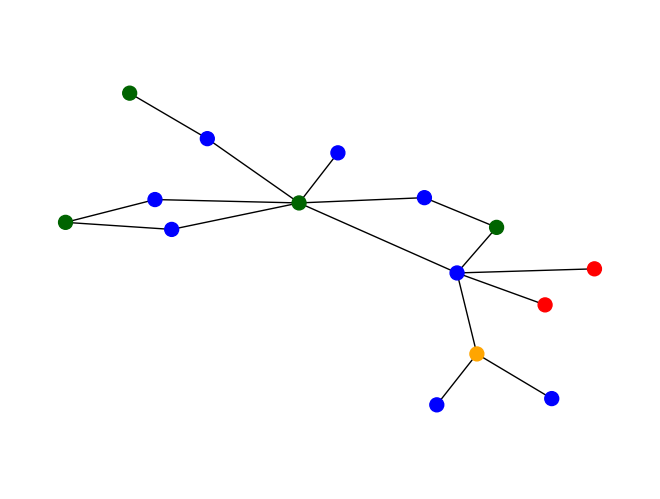

In [56]:
explanation_graph0 = plot_graph(class0_graphid, max_pred0, 0, all_edges[class0_graphid],graph_dict[class0_graphid])

In [57]:
ind= index_2d(softmax_dict[class0_graphid], max_pred0)[0]
list0= nodefeature_dict[class0_graphid]['author'].numpy()[ind]
Counter(list0)

Counter({0.0: 2})

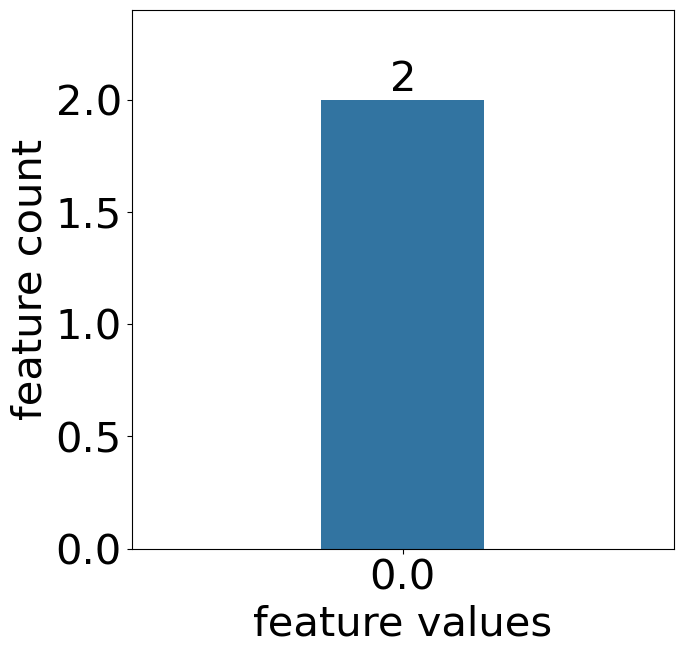

In [58]:
count_plot(list0)

Number of nodes:  15
graph id:  graph1318
Max pred probability for class 1 is 0.9999967813491821


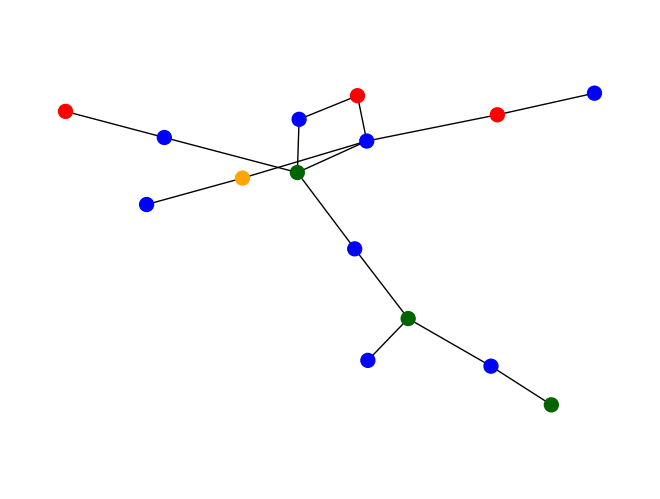

In [59]:
explanation_graph1 = plot_graph(class1_graphid, max_pred1, 1, all_edges[class1_graphid],graph_dict[class1_graphid])

In [60]:
ind= index_2d(softmax_dict[class1_graphid], max_pred1)[0]
list1= nodefeature_dict[class1_graphid]['author'].numpy()[ind]
Counter(list1)

Counter({0.0: 2})

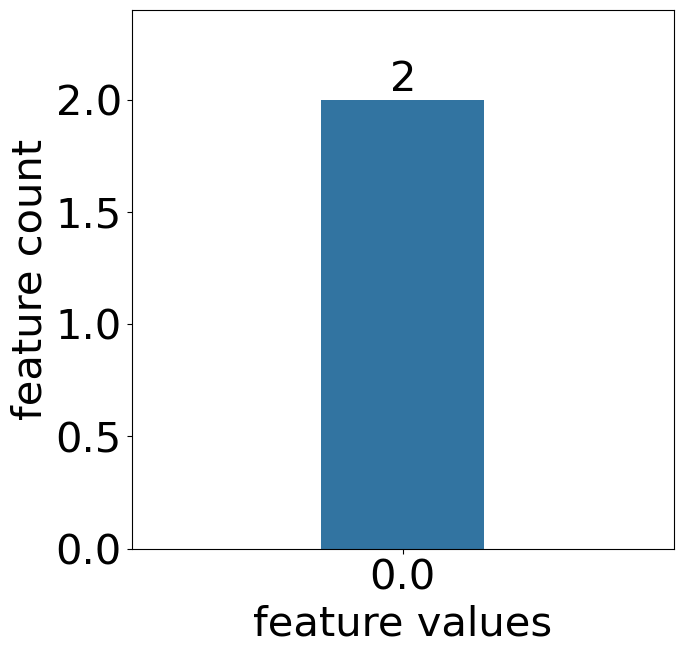

In [61]:
count_plot(list1)

Number of nodes:  14
graph id:  graph955
Max pred probability for class 2 is 0.9999998807907104


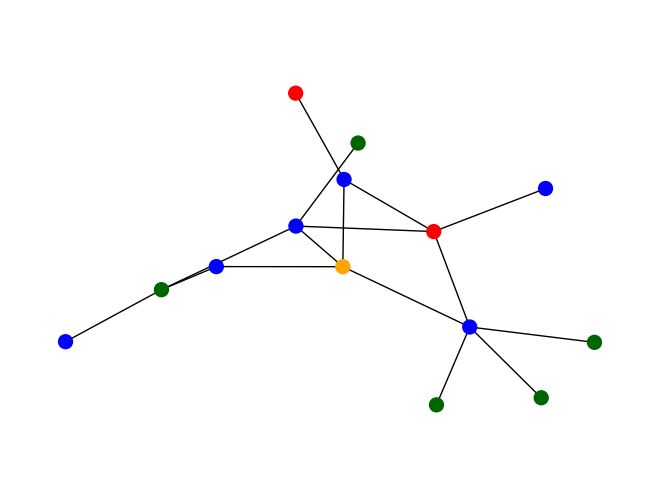

In [62]:
explanation_graph2 = plot_graph(class2_graphid, max_pred2, 2, all_edges[class2_graphid],graph_dict[class2_graphid])

In [63]:
ind= index_2d(softmax_dict[class2_graphid], max_pred2)[0]
list2= nodefeature_dict[class2_graphid]['author'].numpy()[ind]
Counter(list2)

Counter({1.0: 2})

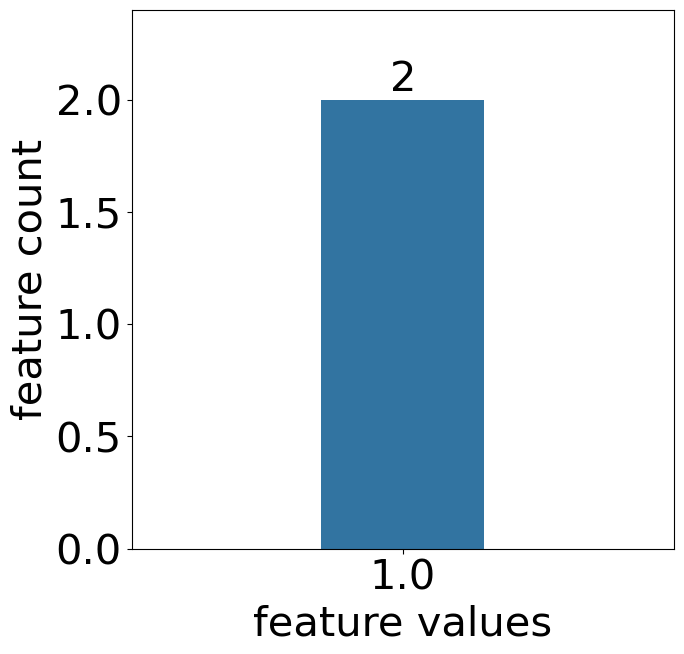

In [64]:
count_plot(list2)

Number of nodes:  14
graph id:  graph977
Max pred probability for class 3 is 0.9992815852165222


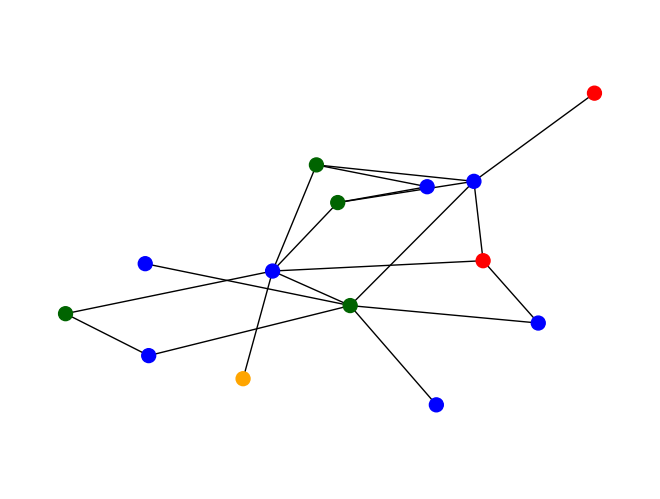

In [65]:
explanation_graph3 = plot_graph(class3_graphid, max_pred3, 3, all_edges[class3_graphid],graph_dict[class3_graphid])

In [66]:
ind= index_2d(softmax_dict[class3_graphid], max_pred3)[0]
list3= nodefeature_dict[class3_graphid]['author'].numpy()[ind]
Counter(list3)

Counter({1.0: 2})

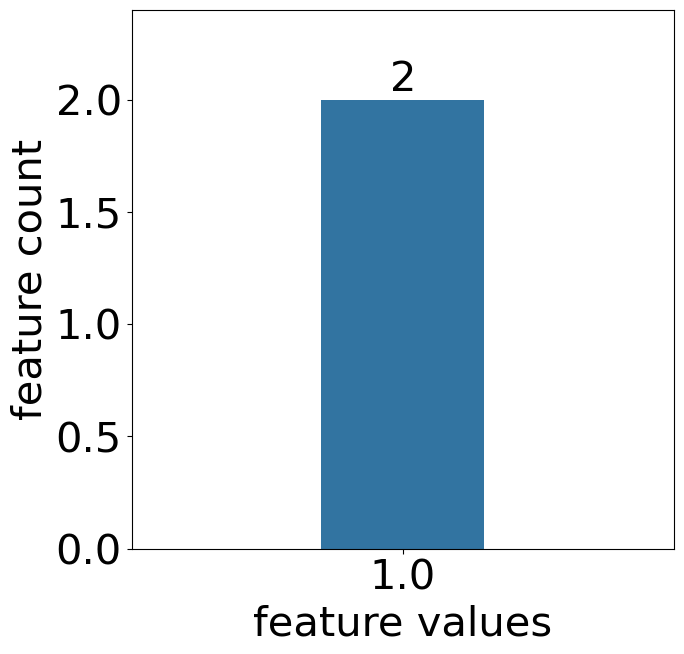

In [67]:
count_plot(list3)

In [68]:
def print_stat_cont_features(df):
    print('mean',df.stack().mean())
    print('std dev',df.stack().std())

In [69]:
def plot_node_feat(imp_feat):
    sns.distplot(imp_feat,color= 'orange',hist= False)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('Feature values',fontsize=20)
    plt.ylabel('Density',fontsize=20)

    plt.show()  

In [70]:
def feature_selection(df_sampled):
    col_sum = df_sampled.sum(axis=0)
    sorted_colsum = sorted(col_sum, reverse=True)

    index_list = []
    for i in sorted_colsum[:1]:
        index_list.append(list(col_sum).index(i))
        imp_feat = df_sampled[index_list].reset_index(drop=True)
        return imp_feat

In [71]:
#Term Feature Statistics
term0_df = pd.DataFrame(nodefeature_dict[class0_graphid]['term'].numpy())
print_stat_cont_features(term0_df)

mean -0.075021155
std dev 0.69500774


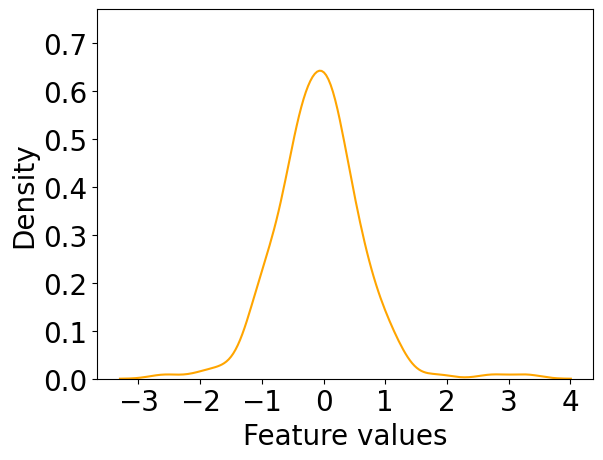

In [72]:
plot_node_feat(term0_df)

In [73]:
term1_df = pd.DataFrame(nodefeature_dict[class1_graphid]['term'].numpy())
print_stat_cont_features(term1_df)

mean 0.06966271
std dev 0.6791762


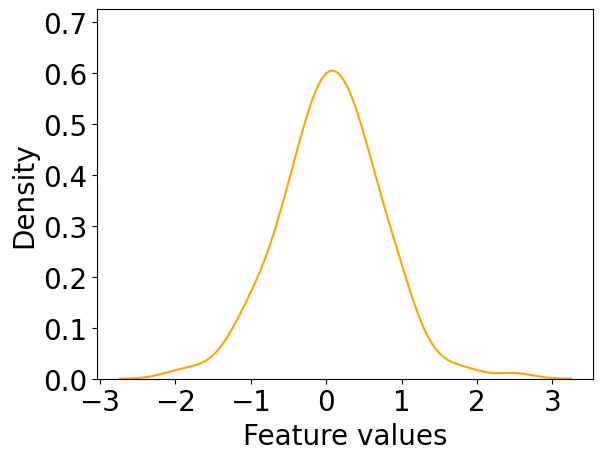

In [74]:
plot_node_feat(term1_df)

In [75]:
term2_df = pd.DataFrame(nodefeature_dict[class2_graphid]['term'].numpy())
print_stat_cont_features(term2_df)

mean 0.00932674
std dev 0.6990912


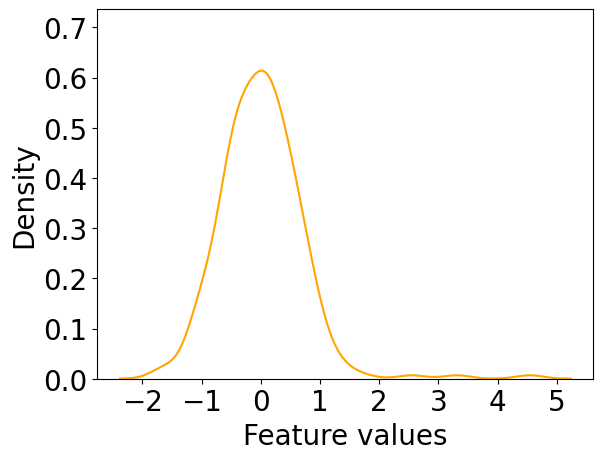

In [76]:
plot_node_feat(term2_df)

In [77]:
term3_df = pd.DataFrame(nodefeature_dict[class3_graphid]['term'].numpy())
print_stat_cont_features(term3_df)

mean -0.02829504
std dev 0.6490047


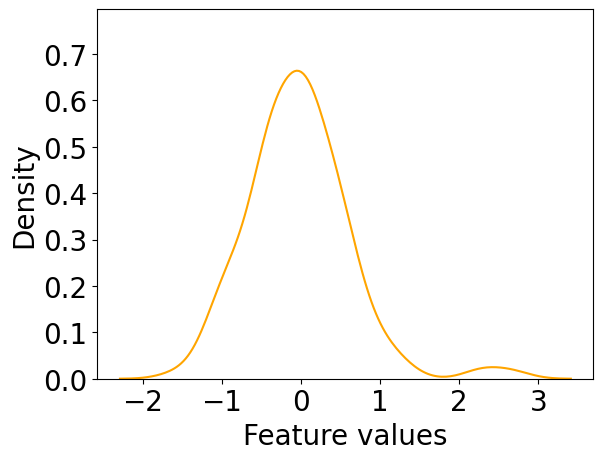

In [78]:
plot_node_feat(term3_df)

In [79]:
#Paper Features
paper0_df = pd.DataFrame(nodefeature_dict[class0_graphid]['paper'].numpy())

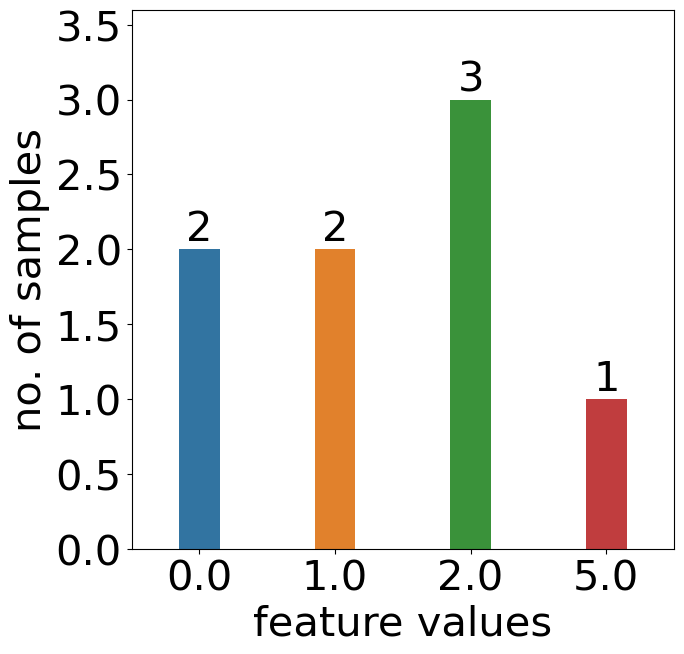

In [80]:
imp_paper_feat0=feature_selection(paper0_df)
plot_imp_feature(imp_paper_feat0.values.tolist())

In [81]:
paper1_df = pd.DataFrame(nodefeature_dict[class1_graphid]['paper'].numpy())

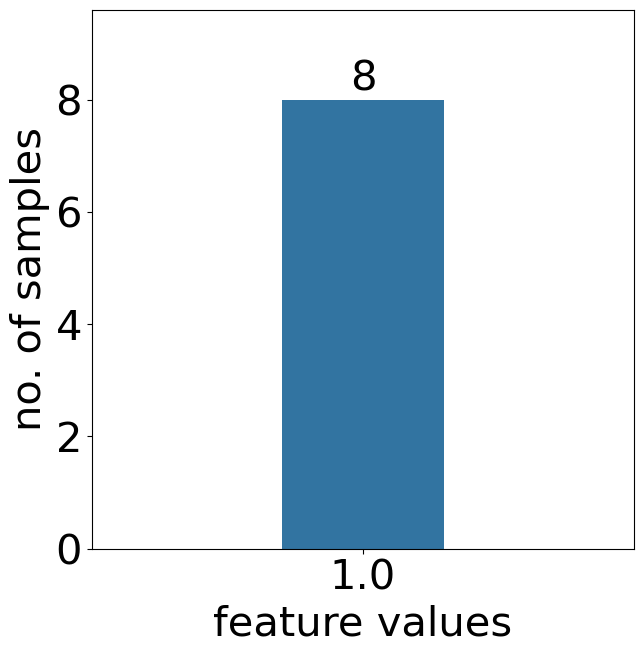

In [82]:
imp_paper_feat1=feature_selection(paper1_df)
plot_imp_feature(imp_paper_feat1.values.tolist())

In [83]:
paper2_df = pd.DataFrame(nodefeature_dict[class2_graphid]['paper'].numpy())

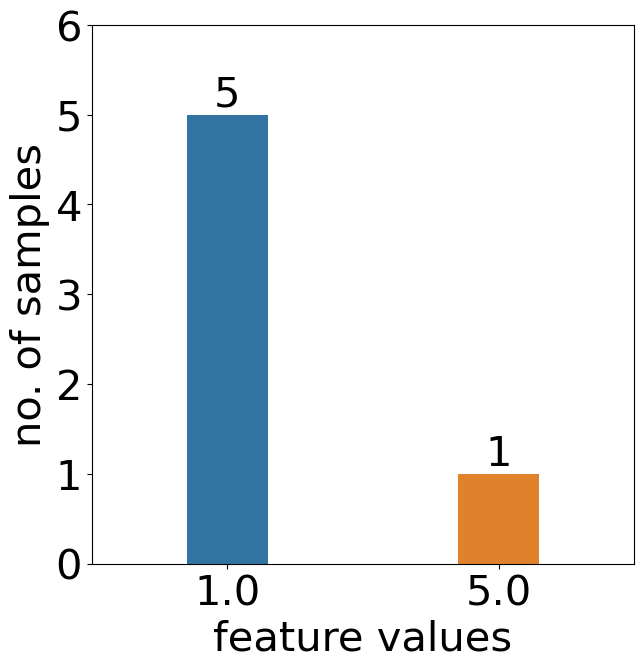

In [84]:
imp_paper_feat2=feature_selection(paper2_df)
plot_imp_feature(imp_paper_feat2.values.tolist())

In [85]:
paper3_df = pd.DataFrame(nodefeature_dict[class3_graphid]['paper'].numpy())

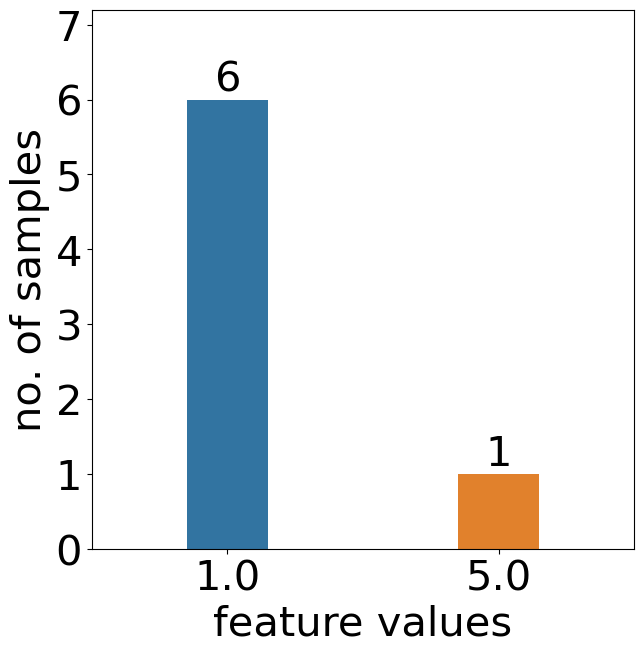

In [86]:
imp_paper_feat3=feature_selection(paper3_df)
plot_imp_feature(imp_paper_feat3.values.tolist())

In [87]:
motifs_path = 'motif_pytorch_real/dblp_10to15/'
files_motif = os.listdir(motifs_path)
files_motif

['motif_real_10_0.gexf',
 'motif_real_10_1.gexf',
 'motif_real_10_2.gexf',
 'motif_real_10_3.gexf',
 'motif_real_10_4.gexf',
 'motif_real_11_0.gexf',
 'motif_real_11_1.gexf',
 'motif_real_11_2.gexf',
 'motif_real_11_3.gexf',
 'motif_real_11_4.gexf',
 'motif_real_12_0.gexf',
 'motif_real_12_1.gexf',
 'motif_real_12_2.gexf',
 'motif_real_12_3.gexf',
 'motif_real_12_4.gexf',
 'motif_real_13_0.gexf',
 'motif_real_13_1.gexf',
 'motif_real_13_2.gexf',
 'motif_real_13_3.gexf',
 'motif_real_13_4.gexf',
 'motif_real_14_0.gexf',
 'motif_real_14_1.gexf',
 'motif_real_14_2.gexf',
 'motif_real_14_3.gexf',
 'motif_real_14_4.gexf',
 'motif_real_15_0.gexf',
 'motif_real_15_1.gexf',
 'motif_real_15_2.gexf',
 'motif_real_15_3.gexf',
 'motif_real_15_4.gexf']

## Edit Distance

In [88]:
for index_m, file_m in enumerate(files_motif):
    filepath_m = os.path.join(motifs_path, file_m)
    print(filepath_m)

motif_pytorch_real/dblp_10to15/motif_real_10_0.gexf
motif_pytorch_real/dblp_10to15/motif_real_10_1.gexf
motif_pytorch_real/dblp_10to15/motif_real_10_2.gexf
motif_pytorch_real/dblp_10to15/motif_real_10_3.gexf
motif_pytorch_real/dblp_10to15/motif_real_10_4.gexf
motif_pytorch_real/dblp_10to15/motif_real_11_0.gexf
motif_pytorch_real/dblp_10to15/motif_real_11_1.gexf
motif_pytorch_real/dblp_10to15/motif_real_11_2.gexf
motif_pytorch_real/dblp_10to15/motif_real_11_3.gexf
motif_pytorch_real/dblp_10to15/motif_real_11_4.gexf
motif_pytorch_real/dblp_10to15/motif_real_12_0.gexf
motif_pytorch_real/dblp_10to15/motif_real_12_1.gexf
motif_pytorch_real/dblp_10to15/motif_real_12_2.gexf
motif_pytorch_real/dblp_10to15/motif_real_12_3.gexf
motif_pytorch_real/dblp_10to15/motif_real_12_4.gexf
motif_pytorch_real/dblp_10to15/motif_real_13_0.gexf
motif_pytorch_real/dblp_10to15/motif_real_13_1.gexf
motif_pytorch_real/dblp_10to15/motif_real_13_2.gexf
motif_pytorch_real/dblp_10to15/motif_real_13_3.gexf
motif_pytorc

In [89]:
def get_avg_edit_distance(graphid_list):
    class_avg_edit_distance = []
    for graphid in graphid_list:
        #print(graphid)
        edges = all_edges_list[i][graphid]
        expln_graph = nx.Graph(edges)
        detect_community(expln_graph)
        list_com= nx.community.louvain_communities(expln_graph, seed=123)
        H = expln_graph.subgraph(max(list_com, key=len))
        # nx.draw(G,with_labels=True)
        # plt.show()
        edit_dist_list = []       
        for index_m, file_m in enumerate(files_motif):
            filepath_m = os.path.join(motifs_path, file_m)
            #print(filepath_m)
            motif_graph = nx.read_gexf(filepath_m)
            edit_dist = nx.graph_edit_distance(H, motif_graph)
            #print(edit_dist)
            edit_dist_list.append(edit_dist)
        #print('class average', np.mean(edit_dist_list))
        class_avg_edit_distance.append(np.mean(edit_dist_list))
        
    return np.mean(class_avg_edit_distance) 

In [90]:
avg_edit_distance_list = []
for i in range(0,10):
    avg_edit_distance = get_avg_edit_distance(class_graphid_list[i])

    print('Run'+str(i),avg_edit_distance)
    avg_edit_distance_list.append(avg_edit_distance)
print(np.mean(avg_edit_distance_list))

Run0 4.083333333333333
Run1 3.95
Run2 4.35
Run3 4.133333333333333
Run4 3.8833333333333337
Run5 4.1499999999999995
Run6 3.9833333333333334
Run7 3.9833333333333334
Run8 4.300000000000001
Run9 3.9333333333333336
4.075


## Fidelity

In [91]:
for index_m, file_m in enumerate(files_motif):
    filepath_m = os.path.join(motifs_path, file_m)
    print(filepath_m)

motif_pytorch_real/dblp_10to15/motif_real_10_0.gexf
motif_pytorch_real/dblp_10to15/motif_real_10_1.gexf
motif_pytorch_real/dblp_10to15/motif_real_10_2.gexf
motif_pytorch_real/dblp_10to15/motif_real_10_3.gexf
motif_pytorch_real/dblp_10to15/motif_real_10_4.gexf
motif_pytorch_real/dblp_10to15/motif_real_11_0.gexf
motif_pytorch_real/dblp_10to15/motif_real_11_1.gexf
motif_pytorch_real/dblp_10to15/motif_real_11_2.gexf
motif_pytorch_real/dblp_10to15/motif_real_11_3.gexf
motif_pytorch_real/dblp_10to15/motif_real_11_4.gexf
motif_pytorch_real/dblp_10to15/motif_real_12_0.gexf
motif_pytorch_real/dblp_10to15/motif_real_12_1.gexf
motif_pytorch_real/dblp_10to15/motif_real_12_2.gexf
motif_pytorch_real/dblp_10to15/motif_real_12_3.gexf
motif_pytorch_real/dblp_10to15/motif_real_12_4.gexf
motif_pytorch_real/dblp_10to15/motif_real_13_0.gexf
motif_pytorch_real/dblp_10to15/motif_real_13_1.gexf
motif_pytorch_real/dblp_10to15/motif_real_13_2.gexf
motif_pytorch_real/dblp_10to15/motif_real_13_3.gexf
motif_pytorc

In [92]:
def get_avg_fidelity(graphid_list):
    class_avg_fidelity = []
    for graphid in graphid_list:
        expln_graph = nx.Graph(all_edges[graphid])
        edges = all_edges_list[i][graphid]
        expln_graph = nx.Graph(edges)
        # nx.draw(G,with_labels=True)
        # plt.show()
        fid_score_list = []       
        for index_m, file_m in enumerate(files_motif):
            filepath_m = os.path.join(motifs_path, file_m)
            #print(filepath_m)
            motif_graph = nx.read_gexf(filepath_m)

            GM = nx.algorithms.isomorphism.GraphMatcher(expln_graph,motif_graph)
            x = 1 if GM.subgraph_is_isomorphic() else 0    
            fid_score_list.append(x)

        class_avg_fidelity.append(np.mean(fid_score_list))

    return np.mean(class_avg_fidelity) 

In [93]:
avg_fidelity_list = []

for i in range(0,10):
    avg_fidelity = get_avg_fidelity(class_graphid_list[i])

    print('Run'+str(i),avg_fidelity)
    avg_fidelity_list.append(avg_fidelity)
print(np.mean(avg_fidelity_list))

Run0 0.6666666666666666
Run1 0.7749999999999999
Run2 0.7333333333333333
Run3 0.7
Run4 0.7583333333333333
Run5 0.775
Run6 0.7166666666666667
Run7 0.7
Run8 0.6583333333333334
Run9 0.675
0.7158333333333332
